<a href="https://colab.research.google.com/github/sh2410/Physics-Informed-Quantum-ML/blob/main/Physics_Informed_Quantum_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Physical Constants (SI Units) ---
G = 6.67430e-11  # Gravitational Constant (m^3 kg^-1 s^-2)
M_EARTH = 5.972e24  # Mass of the Earth (kg)
R_EARTH = 6.371e6   # Mean radius of the Earth (m)

# --- Dataset Generation ---
# Generating altitudes from 100km to 2,000km (Low Earth Orbit range)
altitudes = np.linspace(100_000, 2_000_000, 500)
# r = R + h (Distance from the center of the Earth)
distances = R_EARTH + altitudes

# --- Theoretical Physics Calculation ---
# Circular Orbital Velocity Formula: v = sqrt(G*M / r)
orbital_velocities = np.sqrt((G * M_EARTH) / distances)

# --- Data Structuring ---
# Creating a DataFrame for Machine Learning Training
data = {
    'Altitude_m': altitudes,
    'Orbital_Velocity_ms': orbital_velocities
}
df = pd.DataFrame(data)

# Displaying the Physical Dataset
print("Satellite Orbital Data (First 5 samples):")
print(df.head())

Satellite Orbital Data (First 5 samples):
      Altitude_m  Orbital_Velocity_ms
0  100000.000000          7848.326491
1  103807.615230          7846.018484
2  107615.230461          7843.712512
3  111422.845691          7841.408572
4  115230.460922          7839.106661


In [12]:
# --- Machine Learning Pipeline: Orbital Velocity Regression ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Engineering & Target Selection
# Altitude is the independent variable (X), Velocity is the dependent variable (y)
X = df[['Altitude_m']]
y = df['Orbital_Velocity_ms']

# 2. Polynomial Transformation
# Applying degree=2 to capture the non-linear gravitational decay relationship
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. Model Initialization & Convergence
# Fitting a Linear Regression model on the transformed polynomial features
regressor = LinearRegression()
regressor.fit(X_poly, y)

# 4. Performance Metrics Validation
y_pred = regressor.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Model Optimization Complete.")
print(f"R-squared Score: {r2:.6f}") # Precision of the orbital curve fit
print(f"Mean Squared Error: {mse:.4f}")

Model Optimization Complete.
R-squared Score: 0.999993
Mean Squared Error: 0.5515


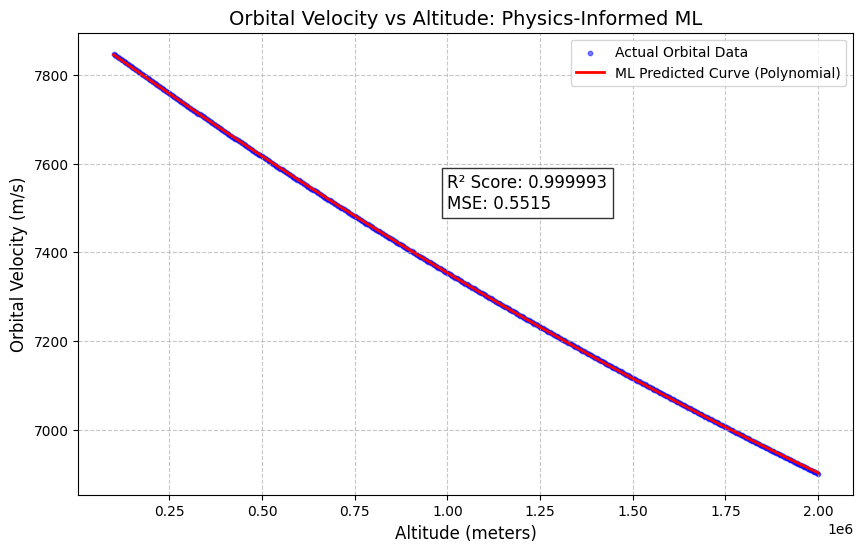

In [13]:
# --- Professional Scientific Visualization ---
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Orbital Data', s=10)
plt.plot(X, y_pred, color='red', linewidth=2, label='ML Predicted Curve (Polynomial)')

plt.title('Orbital Velocity vs Altitude: Physics-Informed ML', fontsize=14)
plt.xlabel('Altitude (meters)', fontsize=12)
plt.ylabel('Orbital Velocity (m/s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Adding the metrics to the plot for professional look
plt.text(1e6, 7500, f'R² Score: {r2:.6f}\nMSE: {mse:.4f}',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.show()

In [14]:
!pip install pennylane

In [15]:
import pennylane as qml
from pennylane import numpy as np


X_norm = (altitudes - altitudes.min()) / (altitudes.max() - altitudes.min()) * np.pi
y_norm = (orbital_velocities - orbital_velocities.min()) / (orbital_velocities.max() - orbital_velocities.min())

dev = qml.device("default.qubit", wires=1)

# (Quantum Layer)
@qml.qnode(dev)
def quantum_model(weights, x):
    qml.RX(x, wires=0)
    qml.RY(weights[0], wires=0)
    qml.RZ(weights[1], wires=0)
    return qml.expval(qml.PauliZ(0))

def cost_function(weights):
    predictions = np.array([quantum_model(weights, x) for x in X_norm[:50]])
    return np.mean((predictions - y_norm[:50])**2)


weights = np.array([0.1, 0.1], requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

print("Starting Quantum Training...")
for i in range(20):
    weights = opt.step(cost_function, weights)
    if i % 5 == 0:
        print(f"Iteration {i} | Cost: {cost_function(weights):.4f}")

print("Quantum Training Complete!")

Starting Quantum Training...
Iteration 0 | Cost: 0.0010
Iteration 5 | Cost: 0.0005
Iteration 10 | Cost: 0.0005
Iteration 15 | Cost: 0.0005
Quantum Training Complete!


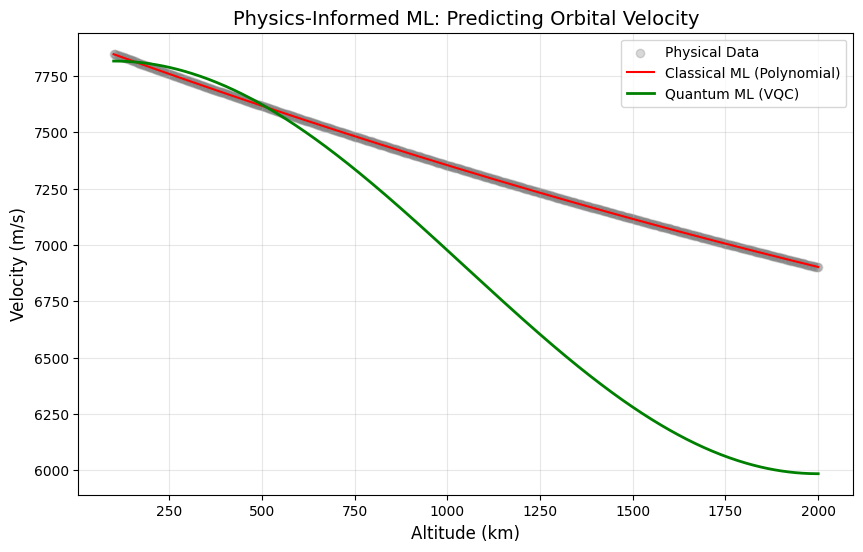

In [16]:
# Extracting Quantum Predictions
q_preds_norm = [quantum_model(weights, x) for x in X_norm]

# Rescaling Quantum Predictions to Physical Units
q_preds_final = np.array(q_preds_norm) * (orbital_velocities.max() - orbital_velocities.min()) + orbital_velocities.min()

# Visualization
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(altitudes/1000, orbital_velocities, color='gray', alpha=0.3, label='Physical Data')
plt.plot(altitudes/1000, y_pred, color='red', label='Classical ML (Polynomial)')
plt.plot(altitudes/1000, q_preds_final, color='green', linewidth=2, label='Quantum ML (VQC)')

plt.title('Physics-Informed ML: Predicting Orbital Velocity', fontsize=14)
plt.xlabel('Altitude (km)', fontsize=12)
plt.ylabel('Velocity (m/s)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()